# Libraries and Setup


In [2]:
import numpy as np
import pandas as pd
import torch
import cv2
import pydicom
from pydicom.uid import ImplicitVRLittleEndian
from pydicom.pixel_data_handlers.util import apply_voi_lut
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as tvm
import os, json, time
import matplotlib.pyplot as plt
import wandb
from tqdm.auto import tqdm
try:
    import timm
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "timm"])
    import timm
try:
    import albumentations as A
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "albumentations"])
    import albumentations as A
    
# Kaggle-specific W&B authentication
from kaggle_secrets import UserSecretsClient

# Disease and Breed classification preprocessing

In [3]:
try:
    import albumentations as A
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "albumentations"])
    import albumentations as A

_aug = A.Compose([
    A.Rotate(limit=7, border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
])

def aumenta(gray):
    return _aug(image=gray)["image"]

In [4]:
CLEAN_CSV = "/kaggle/input/datasets/dariabev/vetxray-c/vetxray_clean-3.csv" 
CACHE_DIR = "/kaggle/working/cache_224"   
WORK      = "/kaggle/working"
os.makedirs(CACHE_DIR, exist_ok=True)

IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], np.float32)

DISEASE_CLASSES = ["cardiomegaly", "alveolar_pattern", "bronchial_pattern", "pleural_effusion","mass", "interstitial_pattern", "pneumothorax", "pleural_mineralization","megaesophagus",]

ENCODERS = ["resnet", "convnext", "swin", "vit"]

SEEDS        = [42, 7, 123, 2024, 99]
EPOCHS       = 50
PATIENCE   = 8 
ES_MONITOR = "val_loss"
ES_MODE    = "min"
BATCH        = 32
LR_HEAD      = 3e-4
LR_BACKBONE  = 5e-6
WEIGHT_DECAY = 1e-2
DROPOUT = 0.5
DROP_PATH = 0.2

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("encoder:", ENCODERS)
print("seed:", SEEDS, "| max epoche:", EPOCHS, "| patience:", PATIENCE)

class EarlyStopper:
    def __init__(self, patience=8, mode="min"):
        self.patience = patience
        self.mode = mode
        self.best = None
        self.senza_miglioramento = 0
    def _migliora(self, v):
        if self.best is None:
            return True
        return v < self.best if self.mode == "min" else v > self.best
    def step(self, v):
        if self._migliora(v):
            self.best = v
            self.senza_miglioramento = 0
            return True, False
        self.senza_miglioramento += 1
        return False, self.senza_miglioramento >= self.patience

device: cuda
encoder: ['resnet', 'convnext', 'swin', 'vit']
seed: [42, 7, 123, 2024, 99] | max epoche: 50 | patience: 8


In [5]:
def dicom_to_gray224(dcm_path):
    ds = pydicom.dcmread(dcm_path, force=True)
    if not hasattr(ds, "file_meta") or ds.file_meta is None:
        ds.file_meta = pydicom.dataset.FileMetaDataset()
    if "TransferSyntaxUID" not in ds.file_meta:
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian
    arr = ds.pixel_array
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        pass
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        arr = arr.max() - arr
    arr = arr.astype(np.float32)
    lo, hi = np.percentile(arr, [1, 99])
    if hi <= lo:
        hi, lo = arr.max(), arr.min()
    arr = np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)
    return cv2.resize((arr * 255).astype(np.uint8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def get_cached_gray(file_name, dcm_path):
    png = os.path.join(CACHE_DIR, file_name.replace(".dcm", ".png"))
    if os.path.exists(png):
        return cv2.imread(png, cv2.IMREAD_GRAYSCALE)
    gray = dicom_to_gray224(dcm_path)
    cv2.imwrite(png, gray)
    return gray

def aumenta(gray):
    if np.random.rand() < 0.5:
        ang = np.random.uniform(-7, 7)
        M = cv2.getRotationMatrix2D((IMG_SIZE / 2, IMG_SIZE / 2), ang, 1.0)
        gray = cv2.warpAffine(gray, M, (IMG_SIZE, IMG_SIZE), borderMode=cv2.BORDER_REFLECT)
    if np.random.rand() < 0.5:
        f = np.random.uniform(0.9, 1.1)
        gray = np.clip(gray.astype(np.float32) * f, 0, 255).astype(np.uint8)
    return gray

def a_tensore(gray):
    x = gray.astype(np.float32) / 255.0
    x = x[..., None].repeat(3, -1)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(x.transpose(2, 0, 1)).float()

BREEDS = sorted(pd.read_csv(CLEAN_CSV).query("has_breed == 1")["breed_label"].unique())
breed2idx = {b: i for i, b in enumerate(BREEDS)}

class VetXRayDataset(Dataset):
    def __init__(self, split, task="disease", augment=False):
        df = pd.read_csv(CLEAN_CSV)
        df = df[df["split"] == split]
        if task == "breed":
            df = df[df["has_breed"] == 1]
        self.df = df.reset_index(drop=True)
        self.task = task
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        gray = get_cached_gray(r["FileName"], r["img_path"])
        if self.augment:
            gray = aumenta(gray)
        img = a_tensore(gray)
        if self.task == "disease":
            y = torch.tensor(r[DISEASE_CLASSES].to_numpy(np.float32))
        else:
            y = torch.tensor(breed2idx[r["breed_label"]], dtype=torch.long)
        return img, y

from tqdm.auto import tqdm
df_all = pd.read_csv(CLEAN_CSV)
ok, err = 0, 0
for _, r in tqdm(df_all.iterrows(), total=len(df_all), desc="cache PNG"):
    try:
        get_cached_gray(r["FileName"], r["img_path"])
        ok += 1
    except Exception:
        err += 1
print(f"\ncache pronta: {ok} immagini | errori: {err}")

cache PNG:   0%|          | 0/7147 [00:00<?, ?it/s]


cache pronta: 7147 immagini | errori: 0


In [6]:
TIMM_NAMES = {
    "vit":      "vit_base_patch16_224",
    "convnext": "convnext_tiny",
    "swin":     "swin_tiny_patch4_window7_224",
}

def make_encoder(nome):
    if nome == "resnet":
        m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
        dim = m.fc.in_features
        m.fc = nn.Identity()
        return m, dim
    if nome in TIMM_NAMES:
        m = timm.create_model(TIMM_NAMES[nome], pretrained=True, num_classes=0,
                              drop_path_rate=DROP_PATH)
        return m, m.num_features
    raise ValueError(f"encoder sconosciuto: {nome}")

class VetXRayNet(nn.Module):
    def __init__(self, n_classes, encoder="resnet"):
        super().__init__()
        self.enc, dim = make_encoder(encoder)
        self.head = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(dim, n_classes))
    def forward(self, img):
        return self.head(self.enc(img))

# sanity check
xb = torch.randn(2, 3, 224, 224, device=device)
for enc in ENCODERS:
    m = VetXRayNet(n_classes=9, encoder=enc).to(device)
    out = m(xb)
    n_tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{enc:10s} -> output {tuple(out.shape)} | parametri {n_tr/1e6:.1f}M")
    del m
    torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s] 


resnet     -> output (2, 9) | parametri 23.5M


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

convnext   -> output (2, 9) | parametri 27.8M


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

swin       -> output (2, 9) | parametri 27.5M


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

vit        -> output (2, 9) | parametri 85.8M


# Disease Classification

In [7]:
def pos_weight_malattia():
    tr = pd.read_csv(CLEAN_CSV).query("split == 'train'")
    pos = tr[DISEASE_CLASSES].sum().to_numpy(np.float32)
    neg = len(tr) - pos
    w = neg / np.maximum(pos, 1)
    w = np.clip(w, 1.0, 10.0)
    return torch.tensor(w, device=device)

def allena_malattia(encoder, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    tr_dl = DataLoader(VetXRayDataset("train", "disease", augment=True),
                       batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    va_dl = DataLoader(VetXRayDataset("val", "disease", augment=False),
                       batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

    model = VetXRayNet(n_classes=9, encoder=encoder).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_malattia())
    opt = torch.optim.AdamW(
        [{"params": model.head.parameters(), "lr": LR_HEAD},
         {"params": model.enc.parameters(),  "lr": LR_BACKBONE}],
        weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda")

    stopper = EarlyStopper(patience=PATIENCE, mode=ES_MODE)
    hist_tr, hist_va, best_state = [], [], None

    for ep in range(1, EPOCHS + 1):
        model.train()
        somma, n = 0.0, 0
        for img, y in tr_dl:
            img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast("cuda"):
                loss = criterion(model(img), y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            somma += loss.item() * len(img)
            n += len(img)
        train_loss = somma / n
        sch.step()

        model.eval()
        somma, n = 0.0, 0
        with torch.no_grad():
            for img, y in va_dl:
                img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast("cuda"):
                    loss = criterion(model(img), y)
                somma += loss.item() * len(img)
                n += len(img)
        val_loss = somma / n

        hist_tr.append(train_loss)
        hist_va.append(val_loss)

        migliore, fermati = stopper.step(val_loss)
        if migliore:
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  ep{ep:02d}  train {train_loss:.4f}  val {val_loss:.4f}" + ("  *best" if migliore else ""))
        if fermati:
            print(f"  early stop all'epoca {ep}")
            break

    model.load_state_dict(best_state)
    return model, hist_tr, hist_va

In [37]:
user_secrets = UserSecretsClient()
wandb_api_key = user_secrets.get_secret("WANDB_API_KEY")
wandb.login(key=wandb_api_key)

OUT_JSON = f"{WORK}/multiseed_disease_TEST.json"
METRICHE = ["Accuracy", "Precision", "Recall", "F1", "AUC", "AP"]

@torch.no_grad()
def valuta_malattia(model):
    te_dl = DataLoader(VetXRayDataset("test", "disease", augment=False),
                       batch_size=BATCH, num_workers=2, pin_memory=True)
    model.eval()
    P, Y = [], []
    for img, y in te_dl:
        with torch.amp.autocast("cuda"):
            logits = model(img.to(device, non_blocking=True))
        P.append(torch.sigmoid(logits).float().cpu().numpy())
        Y.append(y.numpy())
    P = np.concatenate(P); Y = np.concatenate(Y)
    Yp = (P >= 0.5).astype(int)
    acc  = float(np.mean([accuracy_score(Y[:, i], Yp[:, i]) for i in range(Y.shape[1])]))
    prec = precision_score(Y, Yp, average="macro", zero_division=0)
    rec  = recall_score(Y, Yp, average="macro", zero_division=0)
    f1   = f1_score(Y, Yp, average="macro", zero_division=0)
    aucs = [roc_auc_score(Y[:, i], P[:, i]) for i in range(Y.shape[1]) if 0 < Y[:, i].sum() < len(Y)]
    auc  = float(np.mean(aucs))
    ap   = average_precision_score(Y, P, average="macro")
    return {"Accuracy": acc, "Precision": float(prec), "Recall": float(rec),
            "F1": float(f1), "AUC": auc, "AP": float(ap)}

if os.path.exists(OUT_JSON):
    with open(OUT_JSON) as f: results = json.load(f)
    if any("Accuracy" not in results[e] for e in results):
        print("JSON vecchio (metriche diverse)")
        results = {}
    else:
        print("ripresa: risultati caricati")
else:
    results = {}

for enc in ENCODERS:
    results.setdefault(enc, {"seeds": [], **{m: [] for m in METRICHE}})
    
    for seed in SEEDS:
        if seed in results[enc]["seeds"]:
            print(f"salto {enc} seed {seed} (già fatto)"); continue
            
        print(f"\n=== {enc} | seed {seed} ===")
        
        run = wandb.init(
            project="xray-vet-classification",
            group=enc,
            name=f"{enc}_seed_{seed}",
            config={"encoder": enc, "seed": seed},
            reinit=True
        )
        
        model, hist_tr, hist_va = allena_malattia(enc, seed)
        
        for epoch, (tr_loss, va_loss) in enumerate(zip(hist_tr, hist_va)):
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": tr_loss,
                "val_loss": va_loss
            })
            
        m = valuta_malattia(model)
        
        wandb.log({f"test/{k}": v for k, v in m.items()})
        
        results[enc]["seeds"].append(seed)
        for k in METRICHE:
            results[enc][k].append(m[k])
        with open(OUT_JSON, "w") as f: json.dump(results, f)
            
        print("  -> " + " | ".join(f"{k} {m[k]:.3f}" for k in METRICHE))
        
        run.finish()
        
        del model
        torch.cuda.empty_cache()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


ripresa: risultati caricati
salto resnet seed 42 (già fatto)
salto resnet seed 7 (già fatto)
salto resnet seed 123 (già fatto)
salto resnet seed 2024 (già fatto)
salto resnet seed 99 (già fatto)
salto convnext seed 42 (già fatto)
salto convnext seed 7 (già fatto)
salto convnext seed 123 (già fatto)
salto convnext seed 2024 (già fatto)
salto convnext seed 99 (già fatto)
salto swin seed 42 (già fatto)
salto swin seed 7 (già fatto)
salto swin seed 123 (già fatto)
salto swin seed 2024 (già fatto)
salto swin seed 99 (già fatto)
salto vit seed 42 (già fatto)
salto vit seed 7 (già fatto)
salto vit seed 123 (già fatto)
salto vit seed 2024 (già fatto)
salto vit seed 99 (già fatto)


## Disease Ranking Analysis

In [38]:
EPOCHS, PATIENCE, ES_MODE = 50, 8, "min"
LR_HEAD, LR_BACKBONE, WEIGHT_DECAY = 3e-4, 5e-6, 1e-2
DROPOUT, DROP_PATH = 0.5, 0.2
ENC, SEED = "convnext", 99
TIMM_NAMES = {"vit": "vit_base_patch16_224", "convnext": "convnext_tiny", "swin": "swin_tiny_patch4_window7_224"}

class EarlyStopper:
    def __init__(self, patience=8, mode="min"):
        self.patience, self.mode, self.best, self.senza = patience, mode, None, 0
    def step(self, v):
        migliora = self.best is None or (v < self.best if self.mode == "min" else v > self.best)
        if migliora:
            self.best, self.senza = v, 0; return True, False
        self.senza += 1; return False, self.senza >= self.patience

def make_encoder(nome):
    if nome == "resnet":
        m = tvm.resnet50(weights=tvm.ResNet50_Weights.IMAGENET1K_V2)
        dim = m.fc.in_features; m.fc = nn.Identity(); return m, dim
    m = timm.create_model(TIMM_NAMES[nome], pretrained=True, num_classes=0, drop_path_rate=DROP_PATH)
    return m, m.num_features

class VetXRayNet(nn.Module):
    def __init__(self, n_classes, encoder="convnext"):
        super().__init__()
        self.enc, dim = make_encoder(encoder)
        self.head = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(dim, n_classes))
    def forward(self, img):
        return self.head(self.enc(img))

def pos_weight_malattia():
    tr = pd.read_csv(CLEAN_CSV).query("split == 'train'")
    pos = tr[DISEASE_CLASSES].sum().to_numpy(np.float32)
    return torch.tensor(np.clip((len(tr) - pos) / np.maximum(pos, 1), 1.0, 10.0), device=device)

def allena():
    torch.manual_seed(SEED); np.random.seed(SEED)
    tr_dl = DataLoader(VetXRayDataset("train", "disease", augment=True),
                       batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    va_dl = DataLoader(VetXRayDataset("val", "disease", augment=False),
                       batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
    model = VetXRayNet(9, ENC).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_malattia())
    opt = torch.optim.AdamW(
        [{"params": model.head.parameters(), "lr": LR_HEAD},
         {"params": model.enc.parameters(),  "lr": LR_BACKBONE}], weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda")
    stopper = EarlyStopper(PATIENCE, ES_MODE); best_state = None
    for ep in range(1, EPOCHS + 1):
        model.train()
        for img, y in tr_dl:
            img, y = img.to(device), y.to(device)
            opt.zero_grad()
            with torch.amp.autocast("cuda"):
                loss = criterion(model(img), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        sch.step()
        model.eval(); somma, n = 0.0, 0
        with torch.no_grad():
            for img, y in va_dl:
                img, y = img.to(device), y.to(device)
                with torch.amp.autocast("cuda"):
                    loss = criterion(model(img), y)
                somma += loss.item() * len(img); n += len(img)
        migliore, fermati = stopper.step(somma / n)
        if migliore:
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  ep{ep:02d}  val {somma/n:.4f}" + ("  *best" if migliore else ""))
        if fermati: break
    model.load_state_dict(best_state)
    return model

model = allena()
model.eval()

# --- inferenza sul test: probabilita P e verita Y ---
test_df = pd.read_csv(CLEAN_CSV).query("split == 'test'").reset_index(drop=True)
te_dl = DataLoader(VetXRayDataset("test", "disease", augment=False),
                   batch_size=BATCH, num_workers=2, pin_memory=True)
P, Y = [], []
with torch.no_grad():
    for img, y in te_dl:
        P.append(torch.sigmoid(model(img.to(device))).cpu().numpy())
        Y.append(y.numpy())
P = np.concatenate(P)
Y = np.concatenate(Y).astype(int)


K_MAX = 3
accuracy_per_K = {}

for K in range(1, K_MAX + 1):
    hit = 0
    tot = 0
    for i in range(len(Y)):
        vere = np.where(Y[i] == 1)[0]
        if len(vere) == 0:
            continue 
        tot += 1
        top_k = np.argsort(P[i])[::-1][:K]
        if len(set(vere) & set(top_k)) > 0:
            hit += 1
    accuracy_per_K[K] = hit / tot

print(f"\nImmagini valutate (con almeno 1 malattia vera): {tot}")
print("\n=== TOP-K ACCURACY ===")
for K in range(1, K_MAX + 1):
    print(f"  Accuracy@{K} = {accuracy_per_K[K]:.3f}")
print(f"\n  Delta Rank-1 -> Rank-2: +{accuracy_per_K[2]-accuracy_per_K[1]:.3f}")
print(f"  Delta Rank-1 -> Rank-3: +{accuracy_per_K[3]-accuracy_per_K[1]:.3f}")


esempio = None
for i in range(len(Y)):
    vere = set(np.where(Y[i] == 1)[0])
    if not vere:
        continue
    top1 = set(np.argsort(P[i])[::-1][:1])
    top2 = set(np.argsort(P[i])[::-1][:2])
    if len(vere & top1) == 0 and len(vere & top2) > 0:   # Miss@1, Hit@2
        esempio = i
        break

if esempio is not None:
    i = esempio
    ordine = np.argsort(P[i])[::-1]
    print(f"\n=== ESEMPIO PRATICO (immagine {test_df.iloc[i]['FileName']}) ===")
    vere_nomi = [DISEASE_CLASSES[d] for d in np.where(Y[i] == 1)[0]]
    print("Malattie vere (GT):", ", ".join(vere_nomi))
    print("\nPredizioni ordinate per probabilita:")
    for pos, d in enumerate(ordine[:4], start=1):
        marca = "  <-- GT" if Y[i, d] == 1 else ""
        print(f"  {pos}. {DISEASE_CLASSES[d]:24s} ({P[i,d]*100:.0f}%){marca}")
    print("\n  Finestra   Criterio                          Esito")
    for K in [1, 2, 3]:
        top_k = set(ordine[:K])
        hit = len(set(np.where(Y[i]==1)[0]) & top_k) > 0
        print(f"  Rank-{K}    GT tra le prime {K}?               {'Hit (1)' if hit else 'Miss (0)'}")

  ep01  val 0.8395  *best
  ep02  val 0.7676  *best
  ep03  val 0.7384  *best
  ep04  val 0.7107  *best
  ep05  val 0.6758  *best
  ep06  val 0.6734  *best
  ep07  val 0.6684  *best
  ep08  val 0.6589  *best
  ep09  val 0.6687
  ep10  val 0.7025
  ep11  val 0.7007
  ep12  val 0.7024
  ep13  val 0.7056
  ep14  val 0.7204
  ep15  val 0.7500
  ep16  val 0.7925

Immagini valutate (con almeno 1 malattia vera): 585

=== TOP-K ACCURACY ===
  Accuracy@1 = 0.619
  Accuracy@2 = 0.776
  Accuracy@3 = 0.855

  Delta Rank-1 -> Rank-2: +0.157
  Delta Rank-1 -> Rank-3: +0.236

=== ESEMPIO PRATICO (immagine IM-0015-0001-0061.dcm) ===
Malattie vere (GT): cardiomegaly, alveolar_pattern, pleural_effusion, megaesophagus

Predizioni ordinate per probabilita:
  1. bronchial_pattern        (83%)
  2. alveolar_pattern         (75%)  <-- GT
  3. interstitial_pattern     (72%)
  4. pleural_effusion         (71%)  <-- GT

  Finestra   Criterio                          Esito
  Rank-1    GT tra le prime 1?         

## Grad-CAM

  ep01  train 0.9300  val 0.8229  *best
  ep02  train 0.8329  val 0.7482  *best
  ep03  train 0.7400  val 0.7028  *best
  ep04  train 0.6908  val 0.6902  *best
  ep05  train 0.6462  val 0.6961
  ep06  train 0.6072  val 0.6567  *best
  ep07  train 0.5724  val 0.6877
  ep08  train 0.5426  val 0.6684
  ep09  train 0.5173  val 0.6706
  ep10  train 0.4884  val 0.6530  *best
  ep11  train 0.4619  val 0.6787
  ep12  train 0.4481  val 0.6930
  ep13  train 0.4315  val 0.7079
  ep14  train 0.4014  val 0.6731
  ep15  train 0.3818  val 0.7951
  ep16  train 0.3682  val 0.7687
  ep17  train 0.3508  val 0.7917
  ep18  train 0.3353  val 0.8722
  early stop all'epoca 18


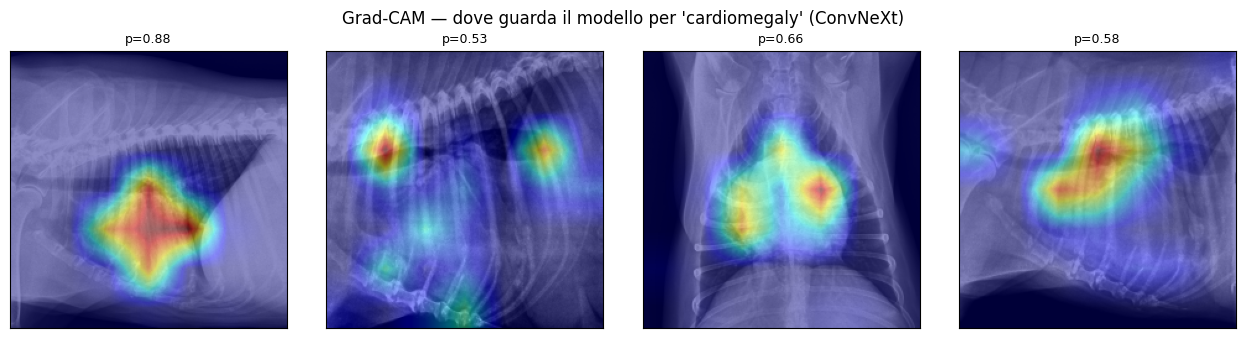

In [12]:
model, _, _ = allena_malattia("convnext", 42)
model.eval()

feature_maps, gradients = {}, {}
def fwd_hook(mod, inp, out): feature_maps["v"] = out
def bwd_hook(mod, gin, gout): gradients["v"] = gout[0]

target_layer = model.enc.stages[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)

CLASSE = "cardiomegaly" 
ci = DISEASE_CLASSES.index(CLASSE)

test_df = pd.read_csv(CLEAN_CSV).query("split == 'test'").reset_index(drop=True)
pos_idx = test_df.index[test_df[CLASSE] == 1].tolist()[:4]

fig, axes = plt.subplots(1, len(pos_idx), figsize=(3.2 * len(pos_idx), 3.4))
for k, idx in enumerate(pos_idx):
    r = test_df.iloc[idx]
    gray = get_cached_gray(r["FileName"], r["img_path"])
    x = a_tensore(gray).unsqueeze(0).to(device)
    x.requires_grad_(True)

    logits = model(x)
    model.zero_grad()
    logits[0, ci].backward()

    fmap = feature_maps["v"][0]
    grad = gradients["v"][0]
    pesi = grad.mean(dim=(1, 2))
    cam = torch.relu((pesi[:, None, None] * fmap).sum(0))   # [7,7]
    cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam.detach().cpu().numpy(), (IMG_SIZE, IMG_SIZE))

    ax = axes[k] if len(pos_idx) > 1 else axes
    ax.imshow(gray, cmap="gray")
    ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"p={torch.sigmoid(logits)[0, ci].item():.2f}", fontsize=9)

h1.remove(); h2.remove()
fig.suptitle(f"Grad-CAM — dove guarda il modello per '{CLASSE}' (ConvNeXt)", fontsize=12)
plt.tight_layout(); plt.savefig(f"{WORK}/gradcam_{CLASSE}.png", dpi=150); plt.show()

# Breed Classification

In [9]:
N_RAZZE = len(BREEDS)

def pesi_razza():
    tr = pd.read_csv(CLEAN_CSV).query("split == 'train' and has_breed == 1")
    idx = tr["breed_label"].map(breed2idx)
    counts = np.array([(idx == i).sum() for i in range(N_RAZZE)], dtype=np.float32)
    w = counts.sum() / (N_RAZZE * np.maximum(counts, 1))
    return torch.tensor(np.clip(w, 0.2, 5.0), device=device)

def allena_razza(encoder, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_dl = DataLoader(VetXRayDataset("train", "breed", augment=True),
                       batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    va_dl = DataLoader(VetXRayDataset("val", "breed", augment=False),
                       batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
    model = VetXRayNet(n_classes=N_RAZZE, encoder=encoder).to(device)
    criterion = nn.CrossEntropyLoss(weight=pesi_razza())
    opt = torch.optim.AdamW(
        [{"params": model.head.parameters(), "lr": LR_HEAD},
         {"params": model.enc.parameters(),  "lr": LR_BACKBONE}], weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda")
    stopper = EarlyStopper(patience=PATIENCE, mode=ES_MODE)
    hist_tr, hist_va, best_state = [], [], None
    for ep in range(1, EPOCHS + 1):
        model.train(); somma, n = 0.0, 0
        for img, y in tr_dl:
            img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)
            opt.zero_grad()
            with torch.amp.autocast("cuda"):
                loss = criterion(model(img), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            somma += loss.item() * len(img); n += len(img)
        train_loss = somma / n; sch.step()
        model.eval(); somma, n = 0.0, 0
        with torch.no_grad():
            for img, y in va_dl:
                img, y = img.to(device, non_blocking=True), y.to(device, non_blocking=True)
                with torch.amp.autocast("cuda"):
                    loss = criterion(model(img), y)
                somma += loss.item() * len(img); n += len(img)
        val_loss = somma / n
        hist_tr.append(train_loss); hist_va.append(val_loss)
        migliore, fermati = stopper.step(val_loss)
        if migliore:
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  ep{ep:02d}  train {train_loss:.4f}  val {val_loss:.4f}" + ("  *best" if migliore else ""))
        if fermati:
            print(f"  early stop all'epoca {ep}"); break
    model.load_state_dict(best_state)
    return model, hist_tr, hist_va

@torch.no_grad()
def valuta_razza(model):
    te_dl = DataLoader(VetXRayDataset("test", "breed", augment=False),
                       batch_size=BATCH, num_workers=2, pin_memory=True)
    model.eval(); P, Y = [], []
    for img, y in te_dl:
        with torch.amp.autocast("cuda"):
            logits = model(img.to(device, non_blocking=True))
        P.append(torch.softmax(logits.float(), 1).cpu().numpy()); Y.append(y.numpy())
    P = np.concatenate(P); Y = np.concatenate(Y); pred = P.argmax(1)
    Yoh = np.eye(N_RAZZE)[Y]
    return {
        "Accuracy":  float(accuracy_score(Y, pred)),
        "BalAcc":    float(balanced_accuracy_score(Y, pred)),
        "Precision": float(precision_score(Y, pred, average="macro", zero_division=0)),
        "Recall":    float(recall_score(Y, pred, average="macro", zero_division=0)),
        "F1":        float(f1_score(Y, pred, average="macro", zero_division=0)),
        "AUC":       float(roc_auc_score(Yoh, P, average="macro", multi_class="ovr")),
        "AP":        float(average_precision_score(Yoh, P, average="macro")),
    }

In [39]:
OUT_JSON_R = f"{WORK}/multiseed_breed_TEST.json"
METRICHE_R = ["Accuracy", "BalAcc", "Precision", "Recall", "F1", "AUC", "AP"]

if os.path.exists(OUT_JSON_R):
    with open(OUT_JSON_R) as f: res_r = json.load(f)
    if any("BalAcc" not in res_r[e] for e in res_r):
        print("partenza pulita"); res_r = {}
    else:
        print("ripresa breed")
else:
    res_r = {}

for enc in ENCODERS:
    res_r.setdefault(enc, {"seeds": [], **{m: [] for m in METRICHE_R}})
    
    for seed in SEEDS:
        if seed in res_r[enc]["seeds"]:
            print(f"salto {enc} seed {seed}"); continue
            
        print(f"\n=== {enc} | seed {seed} (razza) ===")
        
        run = wandb.init(
            project="xray-vet-classification",
            group=f"{enc}_breed",
            name=f"{enc}_seed_{seed}_breed",
            config={
                "encoder": enc, 
                "seed": seed, 
                "task": "breed"
            },
            reinit=True
        )
        
        model, htr, hva = allena_razza(enc, seed)
        
        for epoch, (tr_loss, va_loss) in enumerate(zip(htr, hva)):
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": tr_loss,
                "val_loss": va_loss
            })
            
        m = valuta_razza(model)
        
        wandb.log({f"test/{k}": m[k] for k in METRICHE_R})
        
        res_r[enc]["seeds"].append(seed)
        for k in METRICHE_R: 
            res_r[enc][k].append(m[k])
            
        with open(OUT_JSON_R, "w") as f: 
            json.dump(res_r, f)
            
        print("  -> " + " | ".join(f"{k} {m[k]:.3f}" for k in METRICHE_R))
        
        run.finish()
        del model
        torch.cuda.empty_cache()


=== resnet | seed 42 (razza) ===


  ep01  train 2.2834  val 2.2166  *best
  ep02  train 2.1651  val 2.0950  *best
  ep03  train 2.0567  val 1.9804  *best
  ep04  train 1.9367  val 1.8762  *best
  ep05  train 1.8176  val 1.7760  *best
  ep06  train 1.6816  val 1.6834  *best
  ep07  train 1.5769  val 1.6186  *best
  ep08  train 1.4611  val 1.5453  *best
  ep09  train 1.3702  val 1.4656  *best
  ep10  train 1.2564  val 1.4426  *best
  ep11  train 1.1631  val 1.3818  *best
  ep12  train 1.0689  val 1.3842
  ep13  train 0.9814  val 1.3369  *best
  ep14  train 0.9240  val 1.3024  *best
  ep15  train 0.8414  val 1.2953  *best
  ep16  train 0.7830  val 1.2806  *best
  ep17  train 0.7391  val 1.2633  *best
  ep18  train 0.6898  val 1.2498  *best
  ep19  train 0.6736  val 1.2357  *best
  ep20  train 0.6166  val 1.2414
  ep21  train 0.5973  val 1.2277  *best
  ep22  train 0.5833  val 1.2228  *best
  ep23  train 0.5164  val 1.2192  *best
  ep24  train 0.4929  val 1.2128  *best
  ep25  train 0.4727  val 1.2015  *best
  ep26  train 

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
test/AP,▁
test/AUC,▁
test/Accuracy,▁
test/BalAcc,▁
test/F1,▁
test/Precision,▁
test/Recall,▁
train_loss,██▇▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▆▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,39



=== resnet | seed 7 (razza) ===


  ep01  train 2.2843  val 2.2394  *best
  ep02  train 2.1629  val 2.1113  *best
  ep03  train 2.0647  val 2.0138  *best
  ep04  train 1.9517  val 1.8935  *best
  ep05  train 1.8325  val 1.8072  *best
  ep06  train 1.7104  val 1.7155  *best
  ep07  train 1.5801  val 1.6484  *best
  ep08  train 1.4860  val 1.5749  *best
  ep09  train 1.3891  val 1.5280  *best
  ep10  train 1.2941  val 1.4811  *best
  ep11  train 1.1745  val 1.4263  *best
  ep12  train 1.0898  val 1.4066  *best
  ep13  train 1.0295  val 1.3837  *best
  ep14  train 0.9367  val 1.3494  *best
  ep15  train 0.8789  val 1.3096  *best
  ep16  train 0.8542  val 1.3364
  ep17  train 0.7724  val 1.2916  *best
  ep18  train 0.7294  val 1.2930
  ep19  train 0.6898  val 1.2760  *best
  ep20  train 0.6540  val 1.2924
  ep21  train 0.5944  val 1.2597  *best
  ep22  train 0.5888  val 1.2684
  ep23  train 0.5712  val 1.2637
  ep24  train 0.5044  val 1.2537  *best
  ep25  train 0.5034  val 1.2548
  ep26  train 0.5004  val 1.2573
  ep27  t

...

  ep01  train 2.7514  val 2.1798  *best
  ep02  train 2.3593  val 2.0257  *best
  ep03  train 2.1689  val 1.8550  *best
  ep04  train 1.9826  val 1.7993  *best
  ep05  train 1.8360  val 1.5796  *best
  ep06  train 1.6789  val 1.3742  *best
  ep07  train 1.5457  val 1.3400  *best
  ep08  train 1.4109  val 1.2998  *best
  ep09  train 1.2513  val 1.1717  *best
  ep10  train 1.0467  val 1.2455
  ep11  train 1.0533  val 1.2775
  ep12  train 0.9566  val 1.0493  *best
  ep13  train 0.8105  val 1.2378
  ep14  train 0.7784  val 1.1230
  ep15  train 0.7115  val 1.0525
  ep16  train 0.6603  val 1.1908
  ep17  train 0.6281  val 1.0180  *best
  ep18  train 0.5648  val 1.1043
  ep19  train 0.5408  val 1.0711
  ep20  train 0.4666  val 1.1492
  ep21  train 0.4460  val 1.1083
  ep22  train 0.4228  val 1.1836
  ep23  train 0.3527  val 1.1998
  ep24  train 0.3747  val 1.1718
  ep25  train 0.3853  val 1.3050
  early stop all'epoca 25
  -> Accuracy 0.710 | BalAcc 0.555 | Precision 0.570 | Recall 0.555 | F1

epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
test/AP,▁
test/AUC,▁
test/Accuracy,▁
test/BalAcc,▁
test/F1,▁
test/Precision,▁
test/Recall,▁
train_loss,█▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
val_loss,█▇▆▆▄▃▃▃▂▂▃▁▂▂▁▂▁▂▁▂▂▂▂▂▃
epoch,25



=== vit | seed 99 (razza) ===


  ep01  train 2.7559  val 2.1581  *best
  ep02  train 2.3506  val 2.0190  *best
  ep03  train 2.1686  val 1.8168  *best
  ep04  train 1.9913  val 1.6731  *best
  ep05  train 1.8279  val 1.5023  *best
  ep06  train 1.6517  val 1.4372  *best
  ep07  train 1.5787  val 1.3607  *best
  ep08  train 1.3859  val 1.2891  *best
  ep09  train 1.3020  val 1.2413  *best
  ep10  train 1.2296  val 1.2135  *best
  ep11  train 1.0874  val 1.2435
  ep12  train 1.0532  val 1.1879  *best
  ep13  train 0.9277  val 1.2392
  ep14  train 0.8177  val 1.1696  *best
  ep15  train 0.7621  val 1.2155
  ep16  train 0.7093  val 1.2108
  ep17  train 0.6436  val 1.2328
  ep18  train 0.5759  val 1.2172
  ep19  train 0.5382  val 1.2885
  ep20  train 0.4669  val 1.2107
  ep21  train 0.4436  val 1.3020
  ep22  train 0.4413  val 1.3169
  early stop all'epoca 22
  -> Accuracy 0.694 | BalAcc 0.489 | Precision 0.536 | Recall 0.489 | F1 0.486 | AUC 0.931 | AP 0.532


epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▆▆▆▇▇▇██
test/AP,▁
test/AUC,▁
test/Accuracy,▁
test/BalAcc,▁
test/F1,▁
test/Precision,▁
test/Recall,▁
train_loss,█▇▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁
val_loss,█▇▆▅▃▃▂▂▂▁▂▁▁▁▁▁▁▁▂▁▂▂
epoch,22


## Grad-CAM

  ep01  train 2.5523  val 2.2153  *best
  ep02  train 2.2476  val 1.9178  *best
  ep03  train 2.0685  val 1.7479  *best
  ep04  train 1.8679  val 1.4575  *best
  ep05  train 1.6231  val 1.2874  *best
  ep06  train 1.4693  val 1.1958  *best
  ep07  train 1.2852  val 1.0687  *best
  ep08  train 1.1723  val 1.0901
  ep09  train 1.0246  val 1.0219  *best
  ep10  train 0.9344  val 0.9968  *best
  ep11  train 0.8561  val 0.9720  *best
  ep12  train 0.7249  val 0.9909
  ep13  train 0.7184  val 1.0989
  ep14  train 0.6420  val 1.0182
  ep15  train 0.5828  val 1.1339
  ep16  train 0.5129  val 1.0267
  ep17  train 0.4741  val 1.0143
  ep18  train 0.4851  val 1.0359
  ep19  train 0.4324  val 0.9681  *best
  ep20  train 0.3894  val 1.0728
  ep21  train 0.3760  val 1.0053
  ep22  train 0.3307  val 1.0476
  ep23  train 0.3224  val 1.0324
  ep24  train 0.3309  val 1.0402
  ep25  train 0.3156  val 0.9992
  ep26  train 0.2700  val 1.0387
  ep27  train 0.2734  val 1.0514
  early stop all'epoca 27


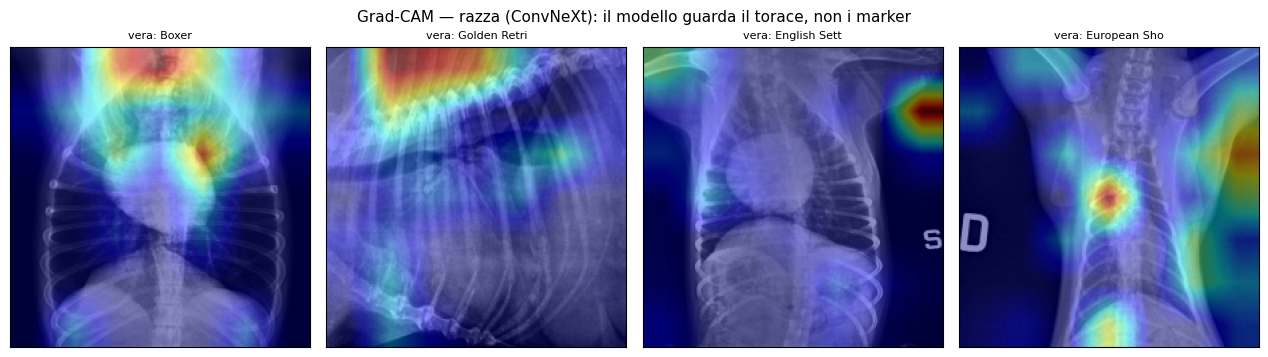

In [11]:
model, _, _ = allena_razza("convnext", 42)
model.eval()

feature_maps, gradients = {}, {}
def fwd_hook(m, i, o): feature_maps["v"] = o
def bwd_hook(m, gi, go): gradients["v"] = go[0]
target_layer = model.enc.stages[-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)

test_df = pd.read_csv(CLEAN_CSV).query("split == 'test' and has_breed == 1").reset_index(drop=True)
scelte = test_df.groupby("breed_label").head(1).head(4)   # 4 razze diverse

fig, axes = plt.subplots(1, len(scelte), figsize=(3.2 * len(scelte), 3.6))
for k, (_, r) in enumerate(scelte.iterrows()):
    gray = get_cached_gray(r["FileName"], r["img_path"])
    x = a_tensore(gray).unsqueeze(0).to(device); x.requires_grad_(True)
    logits = model(x)
    cls = logits.argmax(1).item()
    model.zero_grad(); logits[0, cls].backward()

    fmap, grad = feature_maps["v"][0], gradients["v"][0]
    pesi = grad.mean(dim=(1, 2))
    cam = torch.relu((pesi[:, None, None] * fmap).sum(0))
    cam = (cam / (cam.max() + 1e-8)).detach().cpu().numpy()
    cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    ax = axes[k] if len(scelte) > 1 else axes
    ax.imshow(gray, cmap="gray"); ax.imshow(cam, cmap="jet", alpha=0.45)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"vera: {r['breed_label'][:12]}", fontsize=8)
h1.remove(); h2.remove()
fig.suptitle("Grad-CAM — razza (ConvNeXt): il modello guarda il torace, non i marker", fontsize=11)
plt.tight_layout(); plt.savefig(f"{WORK}/gradcam_razza.png", dpi=150); plt.show()

# Spatial, Frequency and Fusion Analysis

In [9]:
CLEAN_CSV = "/kaggle/input/datasets/dariabev/vetxray-c/vetxray_clean-3.csv"
CACHE_DIR = "/kaggle/working/cache_224"     # cache PNG (o quella committata, sola lettura)
WORK      = "/kaggle/working"
os.makedirs(CACHE_DIR, exist_ok=True)
IMG_SIZE = 224
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], np.float32)

DISEASE_CLASSES = [
    "cardiomegaly", "alveolar_pattern", "bronchial_pattern", "pleural_effusion",
    "mass", "interstitial_pattern", "pneumothorax", "pleural_mineralization",
    "megaesophagus",
]

DINO_VARIANT = "dinov2_vits14"
MODES = ["spatial", "freq", "fusion"]

SEEDS      = [42, 7, 123, 2024, 99]
EPOCHS     = 50
PATIENCE   = 8
ES_MODE    = "min"
BATCH      = 32
LR_HEAD    = 3e-4
WEIGHT_DECAY = 1e-3
DROPOUT    = 0.5
POSW_CAP   = 15

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| DINO:", DINO_VARIANT)
print("modalità:", MODES, "| dropout:", DROPOUT, "| weight decay:", WEIGHT_DECAY)

class EarlyStopper:
    def __init__(self, patience=8, mode="min"):
        self.patience = patience; self.mode = mode
        self.best = None; self.senza = 0
    def _migliora(self, v):
        if self.best is None: return True
        return v < self.best if self.mode == "min" else v > self.best
    def step(self, v):
        if self._migliora(v):
            self.best = v; self.senza = 0
            return True, False
        self.senza += 1
        return False, self.senza >= self.patience

device: cuda | DINO: dinov2_vits14
modalità: ['spatial', 'freq', 'fusion'] | dropout: 0.5 | weight decay: 0.001


In [10]:
def dicom_to_gray224(dcm_path):
    ds = pydicom.dcmread(dcm_path, force=True)
    if not hasattr(ds, "file_meta") or ds.file_meta is None:
        ds.file_meta = pydicom.dataset.FileMetaDataset()
    if "TransferSyntaxUID" not in ds.file_meta:
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian
    arr = ds.pixel_array
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        pass
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        arr = arr.max() - arr
    arr = arr.astype(np.float32)
    lo, hi = np.percentile(arr, [1, 99])
    if hi <= lo:
        hi, lo = arr.max(), arr.min()
    arr = np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)
    return cv2.resize((arr * 255).astype(np.uint8), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

def get_cached_gray(file_name, dcm_path):
    png = os.path.join(CACHE_DIR, file_name.replace(".dcm", ".png"))
    if os.path.exists(png):
        return cv2.imread(png, cv2.IMREAD_GRAYSCALE)
    gray = dicom_to_gray224(dcm_path)
    try:
        cv2.imwrite(png, gray)
    except Exception:
        pass
    return gray

_aug = A.Compose([
    A.Rotate(limit=7, border_mode=cv2.BORDER_REFLECT, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
])
def aumenta(gray):
    return _aug(image=gray)["image"]

def a_tensore(gray):
    x = gray.astype(np.float32) / 255.0
    x = x[..., None].repeat(3, -1)
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return torch.from_numpy(x.transpose(2, 0, 1)).float()

def a_frequenza(gray):
    f = np.fft.fftshift(np.fft.fft2(gray.astype(np.float32)))
    mag = np.log1p(np.abs(f))
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    return a_tensore((mag * 255).astype(np.uint8))

BREEDS = sorted(pd.read_csv(CLEAN_CSV).query("has_breed == 1")["breed_label"].unique())
breed2idx = {b: i for i, b in enumerate(BREEDS)}

class VetXRayDataset(Dataset):
    def __init__(self, split, task="disease", augment=False, return_freq=False):
        df = pd.read_csv(CLEAN_CSV)
        df = df[df["split"] == split]
        if task == "breed":
            df = df[df["has_breed"] == 1]
        self.df = df.reset_index(drop=True)
        self.task = task
        self.augment = augment
        self.return_freq = return_freq
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        r = self.df.iloc[i]
        gray = get_cached_gray(r["FileName"], r["img_path"])
        if self.augment:
            gray = aumenta(gray)
        img = a_tensore(gray)
        if self.task == "disease":
            y = torch.tensor(r[DISEASE_CLASSES].to_numpy(np.float32))
        else:
            y = torch.tensor(breed2idx[r["breed_label"]], dtype=torch.long)
        if self.return_freq:
            return img, a_frequenza(gray), y
        return img, y

print("Dataset pronto | razze:", len(BREEDS))

Dataset pronto | razze: 10


In [11]:
class DinoEncoder(nn.Module):
    def __init__(self, variant=DINO_VARIANT):
        super().__init__()
        self.backbone = torch.hub.load("facebookresearch/dinov2", variant)
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.out_dim = {"dinov2_vits14": 384, "dinov2_vitb14": 768}[variant]
    def forward(self, x):
        with torch.no_grad():
            return self.backbone(x)

class AttnFusion(nn.Module):
    def __init__(self, dim, n_heads=4, p_drop=0.1):
        super().__init__()
        self.modal_emb = nn.Parameter(torch.zeros(2, dim))
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=p_drop, batch_first=True)
        self.norm = nn.LayerNorm(dim)
        nn.init.normal_(self.modal_emb, std=0.02)
    def forward(self, zs, zf):
        seq = torch.stack([zs, zf], dim=1) + self.modal_emb
        att, _ = self.attn(seq, seq, seq, need_weights=False)
        seq = self.norm(seq + att)
        return seq.reshape(seq.size(0), -1)

class DinoNet(nn.Module):
    def __init__(self, n_classes, mode="spatial"):
        super().__init__()
        assert mode in ("spatial", "freq", "fusion")
        self.mode = mode
        self.enc_s = DinoEncoder()
        d = self.enc_s.out_dim
        if mode in ("freq", "fusion"):
            self.enc_f = DinoEncoder()
        if mode == "fusion":
            self.fuse = AttnFusion(d)
            testa_in = 2 * d
        else:
            testa_in = d
        self.head = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(testa_in, n_classes))  # dropout 0.5
    def forward(self, img, freq=None):
        if self.mode == "spatial":
            z = self.enc_s(img)
        elif self.mode == "freq":
            z = self.enc_f(freq)
        else:
            z = self.fuse(self.enc_s(img), self.enc_f(freq))
        return self.head(z)

xb = torch.randn(2, 3, 224, 224, device=device)
for mode in MODES:
    m = DinoNet(n_classes=9, mode=mode).to(device)
    out = m(xb, xb)
    ntr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{mode:8s} -> output {tuple(out.shape)} | trainable {ntr/1e6:.2f}M")
    del m
    torch.cuda.empty_cache()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:03<00:00, 27.2MB/s]


spatial  -> output (2, 9) | trainable 0.00M


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


freq     -> output (2, 9) | trainable 0.00M


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


fusion   -> output (2, 9) | trainable 0.60M


In [12]:
def pos_weight_disease():
    tr = pd.read_csv(CLEAN_CSV).query("split == 'train'")
    pos = tr[DISEASE_CLASSES].sum().to_numpy(np.float32)
    w = np.clip((len(tr) - pos) / np.maximum(pos, 1), 1, POSW_CAP).astype(np.float32)
    return torch.tensor(w, device=device)

def class_weights_breed():
    tr = pd.read_csv(CLEAN_CSV).query("split == 'train' and has_breed == 1")
    idx = tr["breed_label"].map(breed2idx)
    c = np.array([(idx == i).sum() for i in range(len(BREEDS))], dtype=np.float32)
    w = np.clip(c.sum() / (len(BREEDS) * np.maximum(c, 1)), 0.2, 5.0).astype(np.float32)
    return torch.tensor(w, device=device)

def passa(model, batch, need_freq):
    if need_freq:
        img, freq, y = batch
        logits = model(img.to(device, non_blocking=True), freq.to(device, non_blocking=True))
    else:
        img, y = batch
        logits = model(img.to(device, non_blocking=True))
    return logits, y.to(device, non_blocking=True)

def allena(task, mode, seed):
    torch.manual_seed(seed); np.random.seed(seed)
    need_freq = mode in ("freq", "fusion")
    n_classes = 9 if task == "disease" else len(BREEDS)

    tr = VetXRayDataset("train", task=task, augment=True,  return_freq=need_freq)
    va = VetXRayDataset("val",   task=task, augment=False, return_freq=need_freq)
    tr_dl = DataLoader(tr, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    va_dl = DataLoader(va, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

    model = DinoNet(n_classes=n_classes, mode=mode).to(device)
    if task == "disease":
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_disease())
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights_breed())

    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    scaler = torch.amp.GradScaler("cuda")
    stopper = EarlyStopper(patience=PATIENCE, mode=ES_MODE)
    hist_tr, hist_va, best_state = [], [], None

    for ep in range(1, EPOCHS + 1):
        model.train(); somma, n = 0.0, 0
        for batch in tr_dl:
            opt.zero_grad()
            with torch.amp.autocast("cuda"):
                logits, y = passa(model, batch, need_freq)
                loss = criterion(logits, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            somma += loss.item() * len(logits); n += len(logits)
        train_loss = somma / n; sch.step()

        model.eval(); somma, n = 0.0, 0
        with torch.no_grad():
            for batch in va_dl:
                with torch.amp.autocast("cuda"):
                    logits, y = passa(model, batch, need_freq)
                    loss = criterion(logits, y)
                somma += loss.item() * len(logits); n += len(logits)
        val_loss = somma / n
        hist_tr.append(train_loss); hist_va.append(val_loss)
        migliore, fermati = stopper.step(val_loss)
        if migliore:
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  ep{ep:02d}  train {train_loss:.4f}  val {val_loss:.4f}" + ("  *best" if migliore else ""))
        if fermati:
            print(f"  early stop all'epoca {ep}"); break

    model.load_state_dict(best_state)
    return model, hist_tr, hist_va

@torch.no_grad()
def valuta(model, task, mode):
    need_freq = mode in ("freq", "fusion")
    te = VetXRayDataset("test", task=task, augment=False, return_freq=need_freq)
    te_dl = DataLoader(te, batch_size=BATCH, num_workers=2, pin_memory=True)
    model.eval(); P, Y = [], []
    for batch in te_dl:
        logits, y = passa(model, batch, need_freq)
        if task == "disease":
            P.append(torch.sigmoid(logits.float()).cpu().numpy())
        else:
            P.append(torch.softmax(logits.float(), 1).cpu().numpy())
        Y.append(y.cpu().numpy())
    P = np.concatenate(P); Y = np.concatenate(Y)

    if task == "disease":
        Yp = (P >= 0.5).astype(int)
        aucs = [roc_auc_score(Y[:, i], P[:, i]) for i in range(9) if 0 < Y[:, i].sum() < len(Y)]
        return {
            "Accuracy":  float(np.mean([accuracy_score(Y[:, i], Yp[:, i]) for i in range(9)])),
            "Precision": float(precision_score(Y, Yp, average="macro", zero_division=0)),
            "Recall":    float(recall_score(Y, Yp, average="macro", zero_division=0)),
            "F1":        float(f1_score(Y, Yp, average="macro", zero_division=0)),
            "AUC":       float(np.mean(aucs)),
            "AP":        float(average_precision_score(Y, P, average="macro")),
        }
    else:
        pred = P.argmax(1); Yoh = np.eye(len(BREEDS))[Y]
        return {
            "Accuracy":  float(accuracy_score(Y, pred)),
            "BalAcc":    float(balanced_accuracy_score(Y, pred)),
            "Precision": float(precision_score(Y, pred, average="macro", zero_division=0)),
            "Recall":    float(recall_score(Y, pred, average="macro", zero_division=0)),
            "F1":        float(f1_score(Y, pred, average="macro", zero_division=0)),
            "AUC":       float(roc_auc_score(Yoh, P, average="macro", multi_class="ovr")),
            "AP":        float(average_precision_score(Yoh, P, average="macro")),
        }

print("funzioni allena/valuta pronte")

funzioni allena/valuta pronte



=== disease_spatial | seed 42 ===


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  ep01  train 1.3361  val 0.9980  *best
  ep02  train 1.1938  val 0.9827  *best
  ep03  train 1.1148  val 0.9384  *best
  ep04  train 1.0847  val 0.9182  *best
  ep05  train 1.0227  val 0.9115  *best
  ep06  train 1.0082  val 0.9116
  ep07  train 0.9768  val 0.9066  *best
  ep08  train 0.9661  val 0.9153
  ep09  train 0.9493  val 0.9057  *best
  ep10  train 0.9425  val 0.8963  *best
  ep11  train 0.9338  val 0.8821  *best
  ep12  train 0.9237  val 0.8782  *best
  ep13  train 0.9213  val 0.8826
  ep14  train 0.9093  val 0.8815
  ep15  train 0.9103  val 0.8878
  ep16  train 0.8939  val 0.8811
  ep17  train 0.8931  val 0.8766  *best
  ep18  train 0.8943  val 0.8746  *best
  ep19  train 0.8868  val 0.8735  *best
  ep20  train 0.8773  val 0.8891
  ep21  train 0.8832  val 0.8720  *best
  ep22  train 0.8840  val 0.8738
  ep23  train 0.8738  val 0.8771
  ep24  train 0.8800  val 0.8712  *best
  ep25  train 0.8745  val 0.8666  *best
  ep26  train 0.8776  val 0.8679
  ep27  train 0.8794  val 0.86

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
test/AP,▁
test/AUC,▁
test/Accuracy,▁
test/F1,▁
test/Precision,▁
test/Recall,▁
train_loss,█▆▅▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▅▄▃▃▃▄▃▃▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,35
test/AP,0.20302


  -> Accuracy 0.803 | Precision 0.177 | Recall 0.431 | F1 0.237 | AUC 0.730 | AP 0.203

=== disease_spatial | seed 7 ===


...

  -> Accuracy 0.680 | BalAcc 0.489 | Precision 0.514 | Recall 0.489 | F1 0.486 | AUC 0.919 | AP 0.528

=== breed_fusion | seed 99 ===


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


  ep01  train 2.3509  val 1.9560  *best
  ep02  train 2.0732  val 1.7223  *best
  ep03  train 1.8167  val 1.6052  *best
  ep04  train 1.6658  val 1.5676  *best
  ep05  train 1.5336  val 1.5203  *best
  ep06  train 1.4514  val 1.4823  *best
  ep07  train 1.3249  val 1.4400  *best
  ep08  train 1.2999  val 1.4366  *best
  ep09  train 1.2723  val 1.4231  *best
  ep10  train 1.2176  val 1.3921  *best
  ep11  train 1.1247  val 1.3456  *best
  ep12  train 1.0814  val 1.3627
  ep13  train 1.0964  val 1.4362
  ep14  train 1.0284  val 1.4279
  ep15  train 1.0299  val 1.5553
  ep16  train 0.9359  val 1.3402  *best
  ep17  train 0.9400  val 1.4325
  ep18  train 0.9237  val 1.3999
  ep19  train 0.8217  val 1.4016
  ep20  train 0.8223  val 1.4830
  ep21  train 0.8671  val 1.3438
  ep22  train 0.7950  val 1.3244  *best
  ep23  train 0.8091  val 1.4089
  ep24  train 0.8334  val 1.3420
  ep25  train 0.7832  val 1.3830
  ep26  train 0.7604  val 1.3389
  ep27  train 0.7592  val 1.3023  *best
  ep28  tra

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
test/AP,▁
test/AUC,▁
test/Accuracy,▁
test/BalAcc,▁
test/F1,▁
test/Precision,▁
test/Recall,▁
train_loss,█▇▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_loss,█▅▄▄▃▃▂▂▂▂▁▂▂▂▄▁▂▂▂▃▁▁▂▁▂▁▁▁▂▁▂▂▁▁▁
epoch,35


  -> Accuracy 0.685 | BalAcc 0.483 | Precision 0.506 | Recall 0.483 | F1 0.477 | AUC 0.922 | AP 0.526

TEMPO TOTALE: 196.3 min


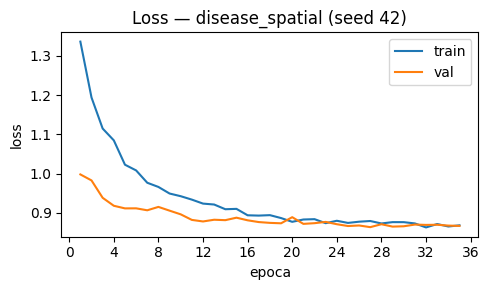

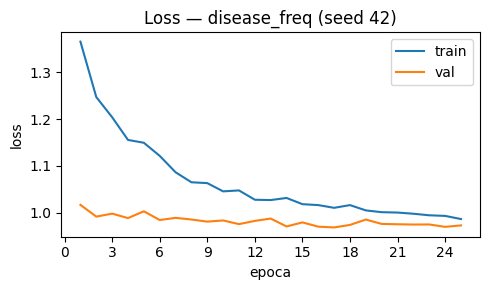

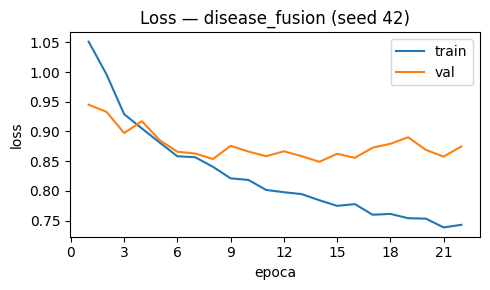

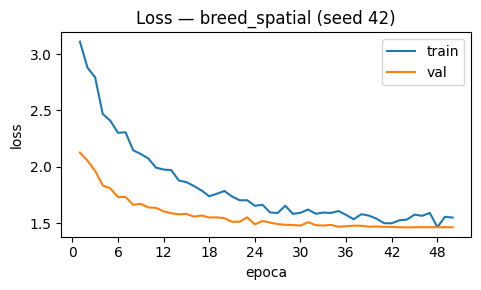

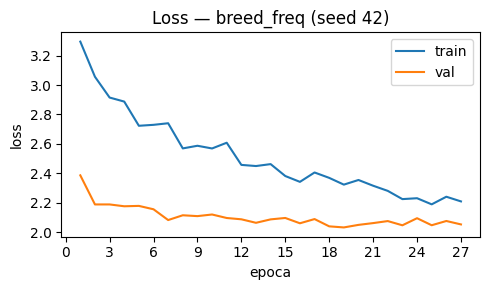

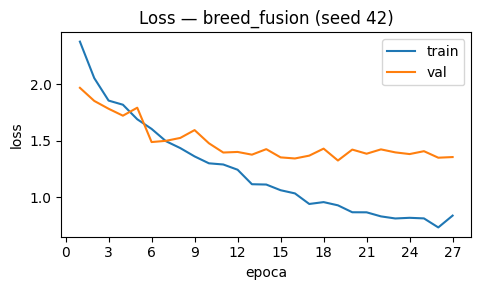

In [45]:
OUT_JSON = f"{WORK}/multiseed_dino_REG.json"

if os.path.exists(OUT_JSON):
    with open(OUT_JSON) as f: results = json.load(f)
    print("ripresa: risultati caricati")
else:
    results = {}

t0 = time.time()
for task in ["disease", "breed"]:
    for mode in MODES:
        chiave = f"{task}_{mode}"
        results.setdefault(chiave, {"seeds": [], "metriche": {}, "hist_tr": [], "hist_va": []})
        for seed in SEEDS:
            if seed in results[chiave]["seeds"]:
                print(f"salto {chiave} seed {seed}"); continue
            print(f"\n=== {chiave} | seed {seed} ===")

            run = wandb.init(
                project="xray-vet-classification",
                name=f"{mode}_seed_{seed}_{task}",
                group=chiave,
                tags=[task, mode, f"seed_{seed}", "dino"],
                config={
                    "task": task, "mode": mode, "seed": seed,
                    "encoder": "dinov2", "epochs": EPOCHS, "lr_head": LR_HEAD,
                    "weight_decay": WEIGHT_DECAY, "dropout": DROPOUT,
                },
                reinit=True,
            )

            model, htr, hva = allena(task, mode, seed)
            m = valuta(model, task, mode)

            for ep in range(len(htr)):
                wandb.log({"epoch": ep + 1, "train_loss": htr[ep], "val_loss": hva[ep]})

            wandb.log({f"test/{k}": v for k, v in m.items()})
            for k, v in m.items():
                wandb.summary[f"test/{k}"] = v

            run.finish()

            results[chiave]["seeds"].append(seed)
            for k, v in m.items():
                results[chiave]["metriche"].setdefault(k, []).append(v)
            if seed == SEEDS[0]:
                results[chiave]["hist_tr"], results[chiave]["hist_va"] = htr, hva
            with open(OUT_JSON, "w") as f: json.dump(results, f)
            print("  -> " + " | ".join(f"{k} {v:.3f}" for k, v in m.items()))
            del model; torch.cuda.empty_cache()

print(f"\nTEMPO TOTALE: {(time.time()-t0)/60:.1f} min")

for chiave in results:
    htr, hva = results[chiave]["hist_tr"], results[chiave]["hist_va"]
    if not htr: continue
    plt.figure(figsize=(5, 3))
    plt.plot(range(1, len(htr)+1), htr, label="train")
    plt.plot(range(1, len(hva)+1), hva, label="val")
    plt.title(f"Loss — {chiave} (seed {SEEDS[0]})")
    plt.xlabel("epoca"); plt.ylabel("loss"); plt.legend()
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.tight_layout(); plt.savefig(f"{WORK}/loss_{chiave}.png", dpi=150); plt.show()

# General information about the data

In [15]:
CLEAN_CSV = "/kaggle/input/datasets/dariabev/vetxray-c/vetxray_clean-3.csv"
SEED = 42

DISEASE_CLASSES = ["cardiomegaly", "alveolar_pattern", "bronchial_pattern", "pleural_effusion",
                   "mass", "interstitial_pattern", "pneumothorax", "pleural_mineralization", "megaesophagus"]

df = pd.read_csv(CLEAN_CSV)
print("righe:", len(df))


def carica_radiografia(dcm_path, size=512):
    ds = pydicom.dcmread(dcm_path, force=True)
    if not hasattr(ds, "file_meta") or ds.file_meta is None:
        ds.file_meta = pydicom.dataset.FileMetaDataset()
    if "TransferSyntaxUID" not in ds.file_meta:
        ds.file_meta.TransferSyntaxUID = ImplicitVRLittleEndian
    arr = ds.pixel_array
    try:
        arr = apply_voi_lut(arr, ds)
    except Exception:
        pass
    if str(getattr(ds, "PhotometricInterpretation", "")).upper() == "MONOCHROME1":
        arr = arr.max() - arr
    arr = arr.astype(np.float32)
    lo, hi = np.percentile(arr, [1, 99])
    if hi <= lo:
        hi, lo = arr.max(), arr.min()
    arr = np.clip((arr - lo) / (hi - lo + 1e-8), 0, 1)
    return cv2.resize(arr, (size, size), interpolation=cv2.INTER_AREA)


def testo_etichetta(riga):
    positivi = [c for c in DISEASE_CLASSES if riga[c] == 1]
    diagnosi = ", ".join(positivi) if positivi else "sano"
    meta = []
    if "specie_norm" in riga.index:
        meta.append(str(riga["specie_norm"]))
    if "breed_label" in riga.index and pd.notna(riga["breed_label"]):
        meta.append(str(riga["breed_label"]))
    if "Projection" in riga.index and pd.notna(riga["Projection"]):
        meta.append(str(riga["Projection"]))
    intestazione = " · ".join(meta)
    return f"{intestazione}\n{diagnosi}" if intestazione else diagnosi

righe: 7147


In [16]:
ANNOT_CSV = "/kaggle/input/datasets/dariabev/annotazioni-con-pazienti/annotazioni_con_pazienti.csv"

annot = pd.read_csv(ANNOT_CSV, dtype=str)
proiezioni = annot[["FileName", "Projection"]].drop_duplicates(subset="FileName", keep="first")

df = df.merge(proiezioni, on="FileName", how="left")
print("proiezioni riattaccate:")
print(df["Projection"].value_counts(dropna=False))

proiezioni riattaccate:
Projection
LL    4235
DV    2168
VD     744
Name: count, dtype: int64


## Projections

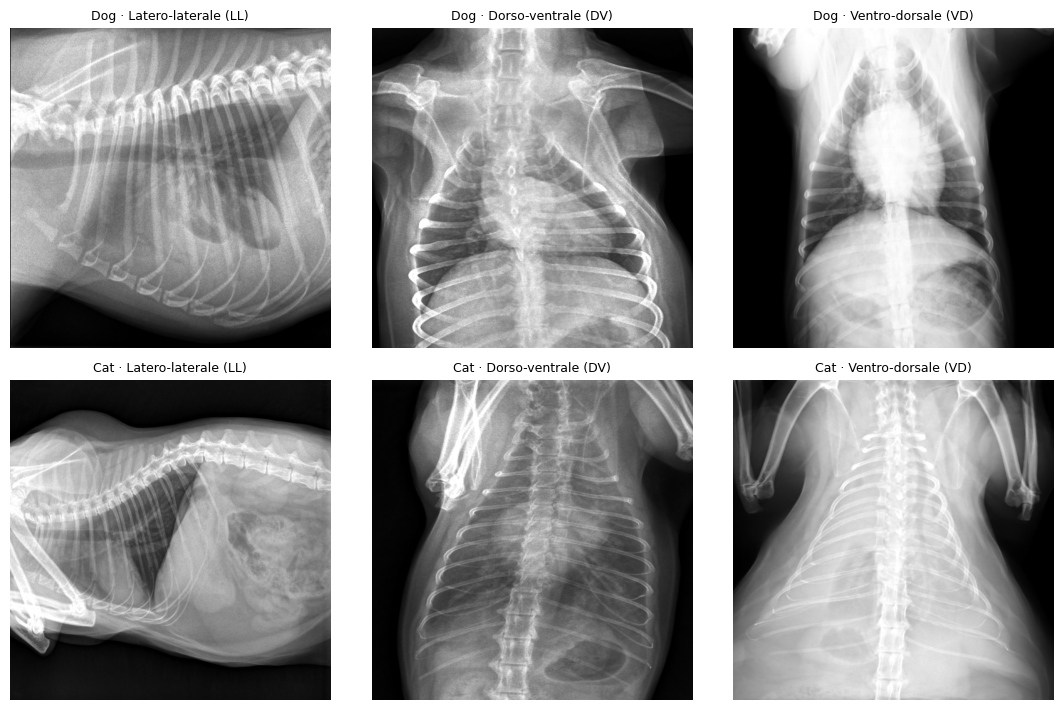

In [ ]:
NOMI_PROIEZIONE = {"LL": "Latero-laterale", "DV": "Dorso-ventrale", "VD": "Ventro-dorsale"}
proiezioni_presenti = ["LL", "DV", "VD"]
specie_presenti = ["Dog", "Cat"]

while True:
    fig, axes = plt.subplots(len(specie_presenti), len(proiezioni_presenti), figsize=(11, 7.2))
    
    for r, specie in enumerate(specie_presenti):
        for c, proj in enumerate(proiezioni_presenti):
            ax = axes[r, c]
            sub = df[(df["specie_norm"] == specie) & (df["Projection"] == proj)]
            
            if len(sub) == 0:
                ax.text(0.5, 0.5, "nessun esempio", ha="center", va="center", fontsize=9)
                ax.axis("off")
                continue
            
            # Ho rimosso il random_state fisso, così pesca casualmente ad ogni giro
            riga = sub.sample(1).iloc[0]
            img = carica_radiografia(riga["img_path"])
            
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{specie} · {NOMI_PROIEZIONE[proj]} ({proj})", fontsize=9)
            ax.axis("off")
            
    plt.tight_layout()
    plt.show()
    
    scelta = input("Questa griglia è pulita? (s/n): ")
    
    if scelta.lower() == 's':
        fig.savefig("/kaggle/working/esempi_specie_proiezione.png", dpi=200, bbox_inches="tight")
        print("Griglia salvata con successo in /kaggle/working/esempi_specie_proiezione.png!")
        break
    else:
        clear_output(wait=True)
        plt.close(fig)